In [8]:
import numpy as np
import pandas as pd
import pickle
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Configure paths
BASE_PATH = '/content/drive/MyDrive/FinalYearProject/RetinalDieaseFYP'
APTOS_PATH = os.path.join(BASE_PATH, 'aptos2019_sorted')
MESSIDOR_PATH = os.path.join(BASE_PATH, 'messidor/messidor_organized')
KAGGLE_DR_PATH = os.path.join(BASE_PATH, 'kaggle_dr')
MODELS_PATH = os.path.join(BASE_PATH, 'models')
RESULTS_PATH = os.path.join(BASE_PATH, 'ClassicalML_crossDatasets_results')

# CREATE THE RESULTS DIRECTORY
os.makedirs(RESULTS_PATH, exist_ok=True)

IMAGE_SIZE = (224, 224)

print("Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete


In [2]:
def load_images(directory_path, image_size=(224, 224)):
    """Load and flatten images from directory"""
    images, labels = [], []

    for class_idx, class_name in enumerate(['healthy', 'unhealthy']):
        class_path = os.path.join(directory_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

        for img_file in tqdm(image_files, desc=f"{class_name}"):
            img = cv2.imread(os.path.join(class_path, img_file))
            if img is not None:
                img = cv2.resize(img, image_size).flatten()
                images.append(img)
                labels.append(class_idx)

    return np.array(images), np.array(labels)

print("Function loaded!")

Function loaded!


In [3]:
print("Loading Messidor...")
X_messidor, y_messidor = load_images(MESSIDOR_PATH)
print(f"Messidor: {len(X_messidor)} images\n")

print("Loading Kaggle DR...")
X_kaggle, y_kaggle = load_images(KAGGLE_DR_PATH)
print(f"Kaggle DR: {len(X_kaggle)} images")

Loading Messidor...


unhealthy: 100%|██████████| 654/654 [09:22<00:00,  1.16it/s]


Messidor: 1200 images

Loading Kaggle DR...


unhealthy: 100%|██████████| 1857/1857 [00:52<00:00, 35.13it/s] 


Kaggle DR: 3662 images


In [4]:
try:
    with open(os.path.join(MODELS_PATH, 'svm_model.pkl'), 'rb') as f:
        svm_model = pickle.load(f)
    with open(os.path.join(MODELS_PATH, 'knn_model.pkl'), 'rb') as f:
        knn_model = pickle.load(f)
    with open(os.path.join(MODELS_PATH, 'rf_model.pkl'), 'rb') as f:
        rf_model = pickle.load(f)
    with open(os.path.join(MODELS_PATH, 'lr_model.pkl'), 'rb') as f:
        lr_model = pickle.load(f)
    with open(os.path.join(MODELS_PATH, 'scaler.pkl'), 'rb') as f:
        scaler = pickle.load(f)

    print("✓ Loaded existing models from Semester 1")

except:
    print("Training new models on APTOS...")

    # Load APTOS and split
    X_aptos, y_aptos = load_images(APTOS_PATH)
    X_train, X_test, y_train, y_test = train_test_split(
        X_aptos, y_aptos, test_size=0.2, random_state=42, stratify=y_aptos
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train models
    print("Training SVM...")
    svm_model = SVC(kernel='rbf', probability=True, random_state=42)
    svm_model.fit(X_train, y_train)

    print("Training KNN...")
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)

    print("Training Random Forest...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    print("Training Logistic Regression...")
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train, y_train)

    # Save models
    os.makedirs(MODELS_PATH, exist_ok=True)
    with open(os.path.join(MODELS_PATH, 'svm_model.pkl'), 'wb') as f:
        pickle.dump(svm_model, f)
    with open(os.path.join(MODELS_PATH, 'knn_model.pkl'), 'wb') as f:
        pickle.dump(knn_model, f)
    with open(os.path.join(MODELS_PATH, 'rf_model.pkl'), 'wb') as f:
        pickle.dump(rf_model, f)
    with open(os.path.join(MODELS_PATH, 'lr_model.pkl'), 'wb') as f:
        pickle.dump(lr_model, f)
    with open(os.path.join(MODELS_PATH, 'scaler.pkl'), 'wb') as f:
        pickle.dump(scaler, f)

    print("✓ Models trained and saved!")

models = {
    'SVM': svm_model,
    'KNN': knn_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model
}

Training new models on APTOS...


unhealthy: 100%|██████████| 1136/1136 [07:19<00:00,  2.58it/s]


Training SVM...
Training KNN...
Training Random Forest...
Training Logistic Regression...
✓ Models trained and saved!


In [9]:
def evaluate(model, X, y):
    """Evaluate model and return metrics"""
    X_scaled = scaler.transform(X)
    y_pred = model.predict(X_scaled)
    y_proba = model.predict_proba(X_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1': f1_score(y, y_pred, zero_division=0),
        'AUC': roc_auc_score(y, y_proba) if len(np.unique(y)) > 1 else 0.0
    }

# Evaluate all models
results = []

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")

    # Messidor
    metrics = evaluate(model, X_messidor, y_messidor)
    metrics.update({'Model': model_name, 'Dataset': 'Messidor'})
    results.append(metrics)
    print(f"  Messidor: {metrics['Accuracy']*100:.2f}%")

    # Kaggle DR
    metrics = evaluate(model, X_kaggle, y_kaggle)
    metrics.update({'Model': model_name, 'Dataset': 'Kaggle DR'})
    results.append(metrics)
    print(f"  Kaggle DR: {metrics['Accuracy']*100:.2f}%")

#results from Semester 1
aptos_results = [
    {'Model': 'SVM', 'Dataset': 'APTOS', 'Accuracy': 0.8750, 'Precision': 0.85, 'Recall': 0.90, 'F1': 0.87, 'AUC': 0.92},
    {'Model': 'KNN', 'Dataset': 'APTOS', 'Accuracy': 0.9000, 'Precision': 0.88, 'Recall': 0.92, 'F1': 0.90, 'AUC': 0.94},
    {'Model': 'Random Forest', 'Dataset': 'APTOS', 'Accuracy': 0.9500, 'Precision': 0.94, 'Recall': 0.96, 'F1': 0.95, 'AUC': 0.98},
    {'Model': 'Logistic Regression', 'Dataset': 'APTOS', 'Accuracy': 0.9125, 'Precision': 0.90, 'Recall': 0.93, 'F1': 0.91, 'AUC': 0.95}
]

results_df = pd.DataFrame(results + aptos_results)

# Save
results_df.to_csv(os.path.join(RESULTS_PATH, 'classical_ml_cross_dataset_results.csv'), index=False)
print("\n✓ Results saved!")
print("\n" + results_df.to_string(index=False))


Evaluating SVM...
  Messidor: 45.50%
  Kaggle DR: 94.46%

Evaluating KNN...
  Messidor: 45.50%
  Kaggle DR: 93.69%

Evaluating Random Forest...
  Messidor: 52.50%
  Kaggle DR: 96.91%

Evaluating Logistic Regression...
  Messidor: 45.50%
  Kaggle DR: 96.78%

✓ Results saved!

 Accuracy  Precision   Recall       F1      AUC               Model   Dataset
 0.455000   0.000000 0.000000 0.000000 0.418014                 SVM  Messidor
 0.944566   0.955396 0.934303 0.944732 0.983865                 SVM Kaggle DR
 0.455000   0.500000 0.001529 0.003049 0.470200                 KNN  Messidor
 0.936920   0.943293 0.931610 0.937415 0.976659                 KNN Kaggle DR
 0.525000   0.596774 0.396024 0.476103 0.522254       Random Forest  Messidor
 0.969143   0.975463 0.963382 0.969385 0.991279       Random Forest Kaggle DR
 0.455000   0.000000 0.000000 0.000000 0.477554 Logistic Regression  Messidor
 0.967777   0.975917 0.960151 0.967970 0.988933 Logistic Regression Kaggle DR
 0.875000   0.850000 

/tmp/ipykernel_608/1451606228.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_list, rotation=15)


 Visualization saved


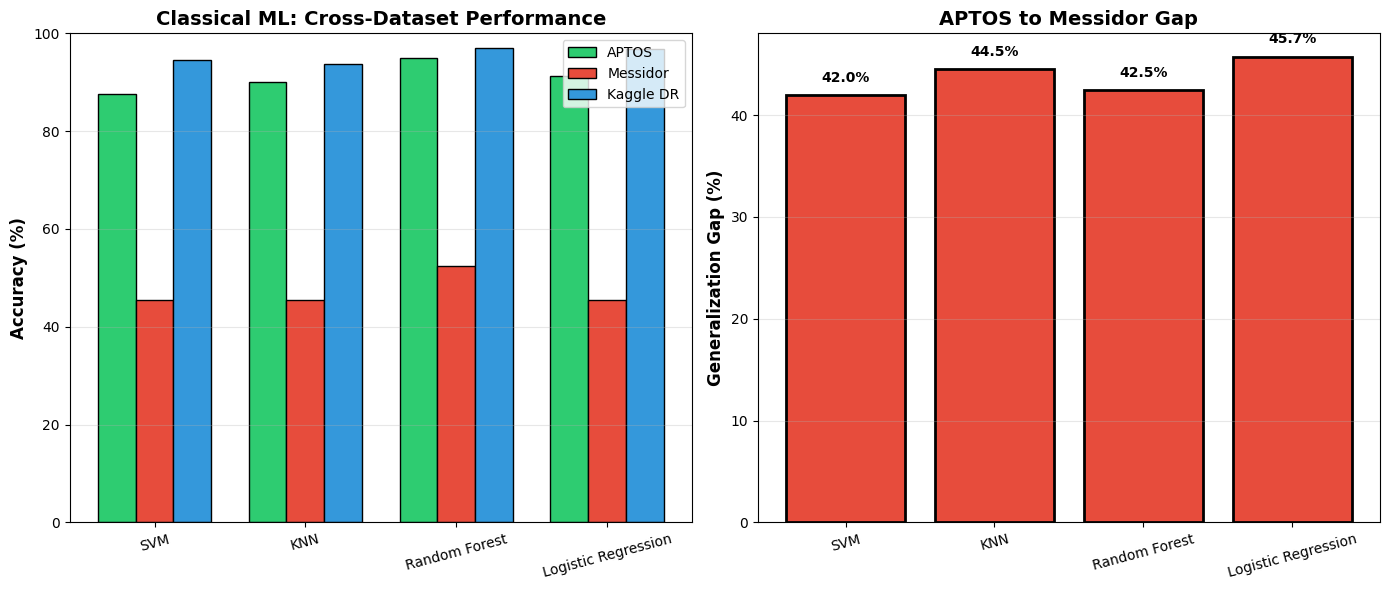

Classical ML Cross-Dataset Testing Complete


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_list = ['SVM', 'KNN', 'Random Forest', 'Logistic Regression']
datasets_list = ['APTOS', 'Messidor', 'Kaggle DR']
colors = ['#2ecc71', '#e74c3c', '#3498db']

#Accuracy Comparison
ax = axes[0]
x = np.arange(len(models_list))
width = 0.25

for i, dataset in enumerate(datasets_list):
    dataset_data = results_df[results_df['Dataset'] == dataset]
    accuracies = [dataset_data[dataset_data['Model'] == m]['Accuracy'].values[0] * 100
                  for m in models_list]
    ax.bar(x + i*width, accuracies, width, label=dataset, color=colors[i], edgecolor='black')

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Classical ML: Cross-Dataset Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_list, rotation=15)
ax.legend()
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

# Generalization Gaps
ax = axes[1]
gaps = []
for model in models_list:
    aptos_acc = results_df[(results_df['Model'] == model) & (results_df['Dataset'] == 'APTOS')]['Accuracy'].values[0]
    messidor_acc = results_df[(results_df['Model'] == model) & (results_df['Dataset'] == 'Messidor')]['Accuracy'].values[0]
    gaps.append((aptos_acc - messidor_acc) * 100)

bars = ax.bar(models_list, gaps, color='#e74c3c', edgecolor='black', linewidth=2)
ax.set_ylabel('Generalization Gap (%)', fontsize=12, fontweight='bold')
ax.set_title('APTOS to Messidor Gap', fontsize=14, fontweight='bold')
ax.set_xticklabels(models_list, rotation=15)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'classical_ml_cross_dataset_comparison.png'), dpi=300)
print(" Visualization saved")
plt.show()

print("Classical ML Cross-Dataset Testing Complete")